In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 06 — E004: CSRNet reproduction on ShanghaiTech Part B

**Goal.** Prove that our CSRNet code (data loading, density maps, model, error calculation) is correct before using it on our own video. We do this on a public dataset with a published result: ShanghaiTech Part B, where CSRNet reports MAE 10.6 and RMSE 16.0 (Li, Zhang & Chen, CVPR 2018).

**What counts as a pass.**
- The official weights, run through our code, give MAE within about 1 of 10.6. This checks our data loading and evaluation.
- Our own training reaches test MAE ≤ 14. Above 20 means a bug.

**Rules.** The test set (316 images) is used once, at the end. Checkpoints are chosen on 40 validation images held out from the 400 training images.

**Why Part B and not our video.** Our video has only 15 labelled frames. A model that has never matched a published number cannot be trusted on our own data. Part B is sparse (about 124 people per image) compared with our frames (about 454), so it is only for checking the code. For our video (E005) we will also run the official Part A weights, which were trained on dense crowds.

## Cell 2 – Setup and data check

We get the latest project code from GitHub, check that a GPU is on, and find the ShanghaiTech Part B folder. Then we pair every image with its label file and count the heads in each. We also check how many head points fall outside the image, which is a known quirk of this dataset. The list is saved as shb_index.csv, and the later cells read everything from it.

In [10]:
import os, re, subprocess, time
from pathlib import Path
import numpy as np, pandas as pd, cv2, scipy.io, torch

REPO_URL = "https://github.com/SagarInspires/crowd-intelligence.git"
REPO_DIR = Path("/kaggle/working/crowd-intelligence")
OUT6 = Path("/kaggle/working/outputs/E004")
INPUT = Path("/kaggle/input")


def sync_repo(url, dest):
    """Clone the project repo into /kaggle/working, or pull the latest commit if it is already there. Prints the commit."""
    if (dest / ".git").exists():
        subprocess.run(["git", "-C", str(dest), "pull", "--quiet"], check=True)
    else:
        subprocess.run(["git", "clone", "--quiet", url, str(dest)], check=True)
    sha = subprocess.run(["git", "-C", str(dest), "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
    print(f"repo at {dest} (commit {sha})")


def find_part(root, part):
    """Find the ShanghaiTech folder for one part (part_A / part_B) anywhere under /kaggle/input, whatever the dataset's
    top-level folder is called. Picks the one that has train_data/ and test_data/ inside."""
    hits = [p for p in root.rglob(part) if p.is_dir() and (p / "train_data").is_dir() and (p / "test_data").is_dir()]
    if not hits:
        raise FileNotFoundError(f"no {part} folder with train_data/test_data under {root} - add the ShanghaiTech dataset as input")
    return sorted(hits, key=lambda p: len(p.parts))[0]


def img_number(path):
    """Image number from a file name like IMG_12.jpg or GT_IMG_12.mat -> 12 (used to pair images with labels)."""
    return int(re.search(r"IMG_(\d+)", path.name).group(1))


def load_points(mat_path):
    """Head points (N x 2, x then y, in pixels) from a ShanghaiTech .mat label file."""
    mat = scipy.io.loadmat(str(mat_path))
    return np.asarray(mat["image_info"][0, 0][0, 0][0], dtype=np.float32).reshape(-1, 2)


def index_split(part_dir, split):
    """Table of one split (train/test): image path, label path, image size, number of heads, and how many head points
    fall outside the image (a known quirk of ShanghaiTech labels). Checks every image has exactly one label file."""
    imgs = {img_number(p): p for p in (part_dir / f"{split}_data" / "images").glob("*.jpg")}
    mats = {img_number(p): p for p in (part_dir / f"{split}_data" / "ground-truth").glob("*.mat")}
    assert imgs.keys() == mats.keys(), f"{split}: images and labels don't pair up"
    rows = []
    for k in sorted(imgs):
        h, w = cv2.imread(str(imgs[k]), cv2.IMREAD_UNCHANGED).shape[:2]
        pts = load_points(mats[k])
        outside = int(((pts[:, 0] < 0) | (pts[:, 0] >= w) | (pts[:, 1] < 0) | (pts[:, 1] >= h)).sum())
        rows.append(dict(id=k, split=split, image=str(imgs[k]), label=str(mats[k]), h=h, w=w, n=len(pts), outside=outside))
    return pd.DataFrame(rows)


def report_gpu():
    """Print which GPU this session has (or warn that it is CPU only - training would be ~50x slower)."""
    if torch.cuda.is_available():
        p = torch.cuda.get_device_properties(0)
        print(f"GPU: {p.name}, {p.total_memory / 1e9:.1f} GB")
    else:
        print("WARNING: no GPU - turn on the accelerator (Settings -> Accelerator -> GPU T4) before training")


# ---- run ---------------------------------------------------------------------------------------------------------
OUT6.mkdir(parents=True, exist_ok=True)
sync_repo(REPO_URL, REPO_DIR)
report_gpu()
PART_B = find_part(INPUT, "part_B")
print("Part B folder:", PART_B)
shb = pd.concat([index_split(PART_B, "train"), index_split(PART_B, "test")], ignore_index=True)
shb.to_csv(OUT6 / "shb_index.csv", index=False)
print(shb.groupby("split").agg(images=("id", "size"), mean_heads=("n", "mean"), min_heads=("n", "min"),
                               max_heads=("n", "max"), total_heads=("n", "sum"), points_outside=("outside", "sum")).round(1))
print("image sizes:", shb.groupby(["h", "w"]).size().to_dict())

repo at /kaggle/working/crowd-intelligence (commit 7a40d9d)
GPU: Tesla T4, 15.6 GB
Part B folder: /kaggle/input/datasets/tthien/shanghaitech/ShanghaiTech/part_B
       images  mean_heads  min_heads  max_heads  total_heads  points_outside
split                                                                       
test      316       123.8          9        539        39121               0
train     400       122.9         12        576        49151               0
image sizes: {(768, 1024): 716}


density maps:   0%|          | 0/716 [00:00<?, ?it/s]

maps built in 80s, worst relative sum error = 1.66e-07
       images  heads
role                
test      316  39121
train     360  43602
val        40   5549


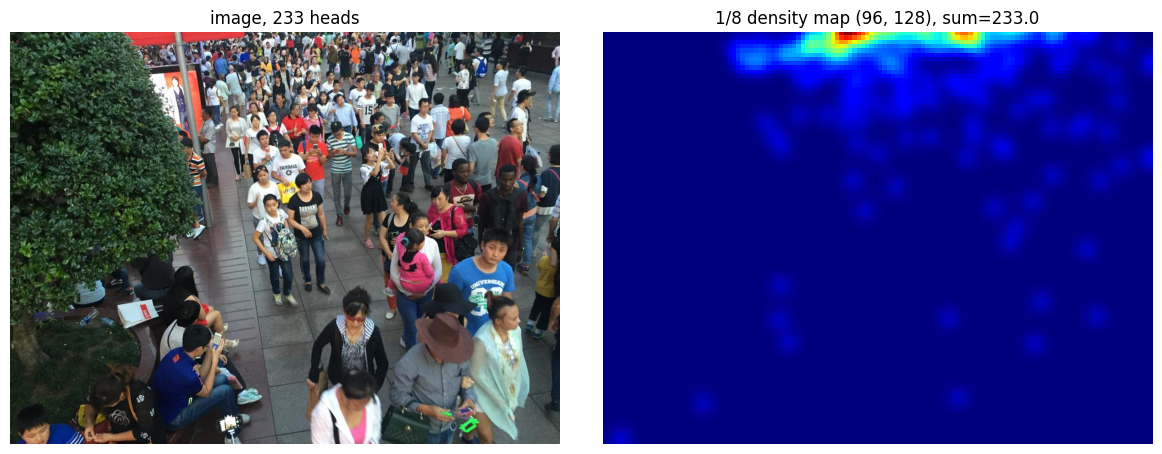

In [11]:
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

SIGMA = 15          # fixed Gaussian width in pixels (original CSRNet recipe for ShanghaiTech B)
FACTOR = 8          # CSRNet output is 1/8 of the input size
N_VAL = 40          # training images held out for validation
SEED = 0
CACHE = Path("/kaggle/working/cache/E004")
CACHE.mkdir(parents=True, exist_ok=True)

def pixel_points(points, h, w):
    """Purpose: round head points to pixels and keep only those inside the image.
    Returns integer (xs, ys). Used by both the density maker and the sum check."""
    if len(points) == 0:
        return np.zeros(0, int), np.zeros(0, int)
    xs = np.round(points[:, 0]).astype(int)
    ys = np.round(points[:, 1]).astype(int)
    ok = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
    return xs[ok], ys[ok]

def make_density(points, h, w, sigma=SIGMA):
    """Purpose: turn head points into a full-size density map whose sum equals the
    number of heads inside the image. Points outside the image are dropped."""
    dens = np.zeros((h, w), np.float32)
    xs, ys = pixel_points(points, h, w)          # step 1-2: nearest pixel, in-image only
    np.add.at(dens, (ys, xs), 1.0)               # step 3: one unit per head (stacks if two share a pixel)
    # step 4: blur; 'reflect' at the border keeps the total exactly unchanged
    return gaussian_filter(dens, sigma, mode="reflect")

def sum_pool(dens, factor=FACTOR):
    """Purpose: shrink the map by `factor` while ADDING the values in each block,
    so the total count is preserved (averaging would break the count)."""
    h, w = dens.shape
    assert h % factor == 0 and w % factor == 0, f"{h}x{w} not divisible by {factor}"
    return dens.reshape(h // factor, factor, w // factor, factor).sum(axis=(1, 3))

def build_cache(table):
    """Purpose: build and save the 1/8-size density map of every image, and check
    that each map's sum matches its number of in-image heads."""
    worst = 0.0
    for r in tqdm(list(table.itertuples()), desc="density maps"):
        pts = load_points(r.label)
        d8 = sum_pool(make_density(pts, r.h, r.w)).astype(np.float32)
        inside = len(pixel_points(pts, r.h, r.w)[0])   # heads that really went into the map
        rel = abs(float(d8.sum()) - inside) / max(inside, 1)
        worst = max(worst, rel)
        np.save(CACHE / f"{r.split}_{r.id}.npy", d8)
    return worst

def add_val_split(table, n_val=N_VAL, seed=SEED):
    """Purpose: mark n_val random training images as 'val' (test is never touched)."""
    t = table.copy()
    t["role"] = t["split"]
    rng = np.random.default_rng(seed)
    tr = t.index[t["split"] == "train"].to_numpy()
    t.loc[rng.choice(tr, n_val, replace=False), "role"] = "val"
    return t

# ---- run ----
t0 = time.time()
worst = build_cache(shb)
print(f"maps built in {time.time()-t0:.0f}s, worst relative sum error = {worst:.2e}")
assert worst < 1e-3, "density sum does not match head count"

shb = add_val_split(shb)
shb.to_csv(OUT6 / "shb_index.csv", index=False)
print(shb.groupby("role").agg(images=("id", "count"), heads=("n", "sum")))

# ---- look at one example ----
import matplotlib.pyplot as plt
r = shb[shb.role == "train"].iloc[0]
img = cv2.cvtColor(cv2.imread(str(r.image)), cv2.COLOR_BGR2RGB)
d8 = np.load(CACHE / f"{r.split}_{r.id}.npy")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(img); ax[0].set_title(f"image, {r.n} heads"); ax[0].axis("off")
ax[1].imshow(d8, cmap="jet"); ax[1].set_title(f"1/8 density map {d8.shape}, sum={d8.sum():.1f}"); ax[1].axis("off")
plt.tight_layout(); plt.savefig(OUT6 / "density_example.png", dpi=100); plt.show()

## Cell 4: Build the CSRNet network

## CSRNet is a counting network with three parts:

**Front end** : the first 10 convolution layers of VGG16, already trained on ImageNet. It finds edges, textures and head-like shapes, and shrinks the picture 8 times.

**Back end** : 6 "dilated" convolution layers. They look at a wider area without shrinking further, so the network can judge how crowded a region is.
Output layer: a single 1×1 convolution that produces one number per position. That is the density map, and its sum is the crowd count.

This cell only builds the network and checks it. It checks the size (16,263,489 parameters), that a 768×1024 image gives a 96×128 map, and that the ImageNet weights load. It needs internet to download the VGG16 weights, which you already have on because the repo cloned.

In [12]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MEAN = np.array([0.485, 0.456, 0.406], np.float32)   # ImageNet mean (RGB)
STD = np.array([0.229, 0.224, 0.225], np.float32)    # ImageNet std (RGB)
FRONTEND = [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512]  # VGG16 up to conv4_3
BACKEND = [512, 512, 512, 256, 128, 64]                                     # dilated layers

def make_layers(cfg, in_ch, dilation=1):
    """Purpose: build a stack of 3x3 conv+ReLU layers from a list of widths;
    'M' inserts a 2x2 max-pool. `dilation` widens each conv's view without shrinking."""
    layers = []
    for v in cfg:
        if v == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            layers += [nn.Conv2d(in_ch, v, 3, padding=dilation, dilation=dilation),
                       nn.ReLU(inplace=True)]
            in_ch = v
    return nn.Sequential(*layers)

class CSRNet(nn.Module):
    """Purpose: CSRNet (Li et al., CVPR 2018). Image (B,3,H,W) -> density map (B,1,H/8,W/8).
    Layer names match the original repo so the official weights load without renaming."""
    def __init__(self, imagenet_frontend=False):
        super().__init__()
        self.frontend = make_layers(FRONTEND, 3)
        self.backend = make_layers(BACKEND, 512, dilation=2)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)
        # step 1: original init for the new layers (normal, std 0.01, zero bias)
        for m in list(self.backend.modules()) + [self.output_layer]:
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.constant_(m.bias, 0)
        # step 2: optionally copy ImageNet VGG16 weights into the front end
        if imagenet_frontend:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            self.frontend.load_state_dict(vgg.features[:23].state_dict())  # first 10 convs, same layer order

    def forward(self, x):
        """Purpose: run front end -> back end -> 1x1 output."""
        return self.output_layer(self.backend(self.frontend(x)))

def load_image_tensor(path):
    """Purpose: read an image file as an ImageNet-normalised RGB tensor (3,H,W)."""
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img = (img - MEAN) / STD
    return torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1)))

# ---- checks ----
net = CSRNet(imagenet_frontend=True).to(DEVICE).eval()
n_params = sum(p.numel() for p in net.parameters())
print("parameters:", f"{n_params:,}")
assert n_params == 16_263_489, "size differs from the published CSRNet"

with torch.no_grad():
    out = net(torch.zeros(1, 3, 768, 1024, device=DEVICE))
print("output shape for 768x1024 input:", tuple(out.shape))
assert tuple(out.shape) == (1, 1, 96, 128)

# ImageNet weights really went in: compare first conv with torchvision's VGG16
vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
same = torch.equal(net.frontend[0].weight.cpu(), vgg.features[0].weight)
print("front end equals ImageNet VGG16 (first conv):", same)
assert same

# one real image through the network (untrained back end, so the count is meaningless)
r = shb[shb.role == "val"].iloc[0]
with torch.no_grad():
    o = net(load_image_tensor(r.image).unsqueeze(0).to(DEVICE))
print("real image ->", tuple(o.shape), "| sum =", round(float(o.sum()), 3), "(meaningless yet)")
del vgg, net

parameters: 16,263,489
output shape for 768x1024 input: (1, 1, 96, 128)
front end equals ImageNet VGG16 (first conv): True
real image -> (1, 1, 96, 128) | sum = -1.649 (meaningless yet)


## Cell 5: Test the official CSRNet weights on Part B

Before training our own, we check that our code reproduces the paper. We load the authors' own trained weights for Part B into our network and count people in all 316 test images.

The paper reports MAE 10.6 (average miss in people per image) and RMSE 16.0.
If we get about 9.6 to 11.6, the network, the image preprocessing and the test loop are all correct.
If we get something far off (say above 20), one of them has a bug. We fix it before spending hours on training.

Before this cell, upload the weights as a private Kaggle dataset named csrnet-official-weights. It needs the two .pth.tar files, Part A and Part B, and you attach it to the notebook as an input.

In [13]:
from tqdm.auto import tqdm

def find_weights(root, part_letter):
    """Purpose: find the official checkpoint for 'A' or 'B' anywhere under /kaggle/input."""
    files = [p for p in Path(root).rglob("*") if p.is_file() and (p.suffix == ".tar" or p.suffix == ".pth")]
    key = f"part{part_letter}".lower()
    hit = [p for p in files if key in p.name.lower().replace("_", "").replace("-", "")]
    if not hit:
        raise FileNotFoundError(f"no Part {part_letter} weights found. Checkpoint-like files seen: {[str(p) for p in files]}")
    return hit[0]

def load_official(model, path):
    """Purpose: load an official CSRNet checkpoint (.pth.tar) into `model`; strict, so
    any mismatch in layer names or shapes fails loudly."""
    ckpt = torch.load(path, map_location="cpu", weights_only=False)   # trusted file we uploaded ourselves
    sd = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
    sd = {k.replace("module.", "", 1): v for k, v in sd.items()}      # drop DataParallel prefix if present
    model.load_state_dict(sd, strict=True)
    return ckpt

@torch.no_grad()
def evaluate(model, table, desc="testing"):
    """Purpose: predict the count for every image in `table` (full size, one at a time)
    and return a table with the true count, predicted count and error."""
    model.eval()
    rows = []
    for r in tqdm(list(table.itertuples()), desc=desc, leave=False):
        x = load_image_tensor(r.image).unsqueeze(0).to(DEVICE)
        pred = float(model(x).sum().item())
        rows.append(dict(id=r.id, gt=int(r.n), pred=pred, err=pred - int(r.n)))
    return pd.DataFrame(rows)

def summarize(df):
    """Purpose: MAE, RMSE and mean signed error (bias) of a prediction table."""
    e = df["err"].to_numpy()
    return dict(MAE=float(np.abs(e).mean()), RMSE=float(np.sqrt((e ** 2).mean())), bias=float(e.mean()))

# ---- run ----
wB = find_weights(INPUT, "B")
print("using:", wB)
netB = CSRNet().to(DEVICE)
ckpt = load_official(netB, wB)
print("weights loaded (strict). checkpoint keys:", [k for k in ckpt.keys()] if isinstance(ckpt, dict) else "raw state_dict")

t0 = time.time()
test_df = shb[shb.role == "test"]
resB = evaluate(netB, test_df, desc="official Part B on test")
resB.to_csv(OUT6 / "official_partB_test.csv", index=False)
s = summarize(resB)
print(f"{len(resB)} test images in {time.time()-t0:.0f}s")
print(f"official Part B weights:  MAE {s['MAE']:.2f}   RMSE {s['RMSE']:.2f}   bias {s['bias']:+.2f}   (paper: MAE 10.6, RMSE 16.0)")
print("verdict:", "PASS, code reproduces the paper" if abs(s["MAE"] - 10.6) <= 1.0 else "CHECK: outside +-1 of 10.6")
print("worst 5 images:\n", resB.reindex(resB["err"].abs().sort_values(ascending=False).index).head(5).round(1).to_string(index=False))

using: /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/partBmodel_best.pth.tar
weights loaded (strict). checkpoint keys: ['state_dict', 'epoch', 'arch', 'optimizer', 'best_prec1']


official Part B on test:   0%|          | 0/316 [00:00<?, ?it/s]

316 test images in 55s
official Part B weights:  MAE 9.76   RMSE 15.95   bias -2.87   (paper: MAE 10.6, RMSE 16.0)
verdict: PASS, code reproduces the paper
worst 5 images:
  id  gt  pred    err
 75 539 427.1 -111.9
 80 470 368.8 -101.2
 74 261 194.2  -66.8
 12 513 451.3  -61.7
293 327 375.0   48.0


## Cell 6: Can our training loop learn? (5-image test)

Before the long training run, we test the training code on a **tiny problem.** We take only 5 training images and train on them repeatedly, with no random crops or flips. A working loop should nearly memorise them, so the error should drop a lot and the predicted counts should get close to the true counts.

If the error falls at least 10 times and the counts land within about 20%, the training code is correct.
If the error does not fall, there is a bug, and we fix it now instead of after hours of training.
This test uses the Adam optimiser at a higher rate so that it learns fast in about a minute. The real run in Cell 7 uses the original paper recipe (SGD).
The cell also defines the data loader (random half-size crops and flips) that Cell 7 reuses.

In [ ]:
import random
from tqdm.auto import tqdm

class CrowdSet(torch.utils.data.Dataset):
    """Purpose: gives (image, 1/8 density map) pairs. With augment=True it takes a random
    half-size crop (aligned to multiples of 8 so image and map stay matched) and a random
    horizontal flip, like the original CSRNet training. With augment=False it gives full images."""
    def __init__(self, table, augment, crop=(384, 512)):
        self.rows = list(table.itertuples())
        self.augment, self.crop = augment, crop

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        img = load_image_tensor(r.image)                                       # (3,H,W)
        d8 = torch.from_numpy(np.load(CACHE / f"{r.split}_{r.id}.npy"))[None]  # (1,H/8,W/8)
        if self.augment:
            ch, cw = self.crop
            H, W = img.shape[1:]
            y0 = 8 * random.randint(0, (H - ch) // 8)                  # step 1: random crop corner on the 8-pixel grid
            x0 = 8 * random.randint(0, (W - cw) // 8)
            img = img[:, y0:y0 + ch, x0:x0 + cw]
            d8 = d8[:, y0 // 8:(y0 + ch) // 8, x0 // 8:(x0 + cw) // 8]
            if random.random() < 0.5:                                   # step 2: random horizontal flip of both
                img, d8 = img.flip(-1), d8.flip(-1)
        return img.contiguous(), d8.contiguous()

def make_loader(table, augment, shuffle, workers=2):
    """Purpose: batch-size-1 loader (the original recipe uses one image per step).
    With workers>0 the worker processes stay alive between epochs (persistent_workers),
    so they are not restarted every epoch."""
    return torch.utils.data.DataLoader(CrowdSet(table, augment), batch_size=1, shuffle=shuffle,
                                       num_workers=workers, pin_memory=True,
                                       persistent_workers=workers > 0)

def sum_mse(out, tgt):
    """Purpose: the original CSRNet loss: squared error SUMMED over the map (not averaged)."""
    return ((out - tgt) ** 2).sum()

def train_epoch(model, loader, opt, desc="training"):
    """Purpose: one pass over the loader; returns the mean loss per image."""
    model.train()
    tot, n = 0.0, 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for img, tgt in pbar:
        img, tgt = img.to(DEVICE, non_blocking=True), tgt.to(DEVICE, non_blocking=True)
        loss = sum_mse(model(img), tgt)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        tot += loss.item(); n += 1
        pbar.set_postfix(loss=f"{tot / n:.1f}")           # running mean loss
    return tot / len(loader)

# ---- 5-image overfit test ----
torch.backends.cudnn.benchmark = True
torch.manual_seed(0); random.seed(0)
ov = shb[shb.role == "train"].iloc[:5]
ov_loader = make_loader(ov, augment=False, shuffle=True, workers=0)   # 5 images: load in the main process
net_ov = CSRNet(imagenet_frontend=True).to(DEVICE)
opt = torch.optim.Adam(net_ov.parameters(), lr=1e-5)     # test only; Cell 7 uses the paper's SGD recipe

t0 = time.time()
first = None
for ep in tqdm(range(1, 61), desc="overfit test"):
    L = train_epoch(net_ov, ov_loader, opt, desc="pass")
    first = L if first is None else first
    if ep in (1, 10, 20, 30, 40, 50, 60):
        tqdm.write(f"epoch {ep:2d}  loss/image {L:9.3f}   ({time.time()-t0:.0f}s)")

res = evaluate(net_ov, ov, desc="check 5 images")
print(res.round(1).to_string(index=False))
ratio = first / max(L, 1e-9)
rel = (res["err"].abs() / res["gt"]).max()
print(f"loss fell {ratio:.0f}x;  worst count error {100*rel:.0f}%")
print("verdict:", "PASS, training loop learns" if ratio >= 10 and rel <= 0.20 else "CHECK: paste this output")
del net_ov, opt

## Cell 7: Train CSRNet (the real run)

This is the long run. It trains on the 360 training images with the settings from the CSRNet paper: SGD, learning rate 0.0000001, momentum 0.95, one image per step, random half-size crops and flips, up to 400 passes over the data.

After every pass it scores the 40 validation images and keeps the best model. The 316 test images are not used here.
It saves a checkpoint after every pass (last.pth), so if Kaggle stops it you can run the cell again and it continues where it stopped.
It stops by itself if the validation error has not improved for 40 passes, or after 11 hours, before Kaggle's 12-hour limit.
It writes a log (train_log.csv) and a curve picture.

Why I think it stalls. The paper's recipe uses SGD at a learning rate of 1e-7. With a loss this small, the gradient steps are tiny, so the weights barely move. Our Cell 6 test used Adam at 1e-5 and learned quickly, so the code and targets are fine. This is a guess about the cause, not a proven one, and the SGD run might break out of the plateau after many more epochs. Waiting hours to find out is a bad trade.

What I'd change. Switch to Adam at 1e-5. Cell 6 already showed that setting learns on this code, and to my knowledge some reimplementations of CSRNet use it

In [ ]:
import gc, shutil
from tqdm.auto import tqdm

# ---- choose the recipe ----
OPT = "adam"      # "adam": lr 1e-5 (learned in the Cell 6 test). "sgd": paper recipe lr 1e-7 (stayed flat for 10 epochs, see EXPERIMENTS)
if OPT == "adam":
    EPOCHS, PATIENCE = 200, 30       # stop if val MAE has not improved for PATIENCE epochs
else:
    EPOCHS, PATIENCE = 400, 40
MAX_HOURS = 11.0                     # stop cleanly before Kaggle's 12 h limit (run again to resume)
TAG = f"{OPT}"                       # file names carry the recipe, so runs never overwrite or resume each other
CKPT_DIR = OUT6 / "ckpt"; CKPT_DIR.mkdir(parents=True, exist_ok=True)
LAST_PATH = CKPT_DIR / f"last_{TAG}.pth"
BEST_PATH = CKPT_DIR / f"best_{TAG}.pth"
LOG_CSV = OUT6 / f"train_log_{TAG}.csv"

def make_optimizer(model):
    """Purpose: build the optimiser for the chosen recipe (Adam 1e-5, or the paper's SGD)."""
    if OPT == "adam":
        return torch.optim.Adam(model.parameters(), lr=1e-5)
    return torch.optim.SGD(model.parameters(), lr=1e-7, momentum=0.95, weight_decay=5e-4)

def atomic_save(obj, path):
    """Purpose: write a checkpoint safely (temp file, then rename) so a kill in the
    middle of saving cannot leave a broken file."""
    tmp = Path(str(path) + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)

def find_resume():
    """Purpose: find this recipe's last checkpoint: this session's folder first,
    then any attached input (e.g. the output of a previous notebook version)."""
    if LAST_PATH.exists():
        return LAST_PATH
    hits = sorted(INPUT.rglob(LAST_PATH.name))
    return hits[-1] if hits else None

# ---- free the memory of any earlier run in this kernel ----
for _n in ("model", "opt", "loader"):
    globals().pop(_n, None)
gc.collect(); torch.cuda.empty_cache()

# ---- set up ----
torch.manual_seed(0); random.seed(0)
torch.backends.cudnn.benchmark = True
train_df = shb[shb.role == "train"]
val_df = shb[shb.role == "val"]
model = CSRNet(imagenet_frontend=True).to(DEVICE)
opt = make_optimizer(model)
loader = make_loader(train_df, augment=True, shuffle=True, workers=2)

start, best, bad, log = 1, float("inf"), 0, []
rp = find_resume()
if rp is not None:                                   # resume an interrupted run of the SAME recipe
    ck = torch.load(rp, map_location="cpu", weights_only=False)
    model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
    start, best, bad, log = ck["epoch"] + 1, ck["best"], ck["bad"], ck["log"]
    if rp.parent != CKPT_DIR and (rp.parent / BEST_PATH.name).exists():
        shutil.copy(rp.parent / BEST_PATH.name, BEST_PATH)
    print(f"resuming from {rp} at epoch {start} (best val MAE so far {best:.2f})")
else:
    print(f"starting from scratch with recipe '{OPT}'")

# ---- train ----
t_start = time.time()
bar = tqdm(total=EPOCHS, initial=start - 1, desc="epochs")     # outer bar: whole run, with time left
for ep in range(start, EPOCHS + 1):
    t0 = time.time()
    tl = train_epoch(model, loader, opt, desc=f"epoch {ep} train")   # one pass over 360 training images
    if not np.isfinite(tl):
        tqdm.write("training loss is not finite: stopping"); break
    s = summarize(evaluate(model, val_df, desc=f"epoch {ep} val"))   # 40 validation images, full size
    improved = s["MAE"] < best
    if improved:
        best, bad = s["MAE"], 0
        atomic_save(model.state_dict(), BEST_PATH)
    else:
        bad += 1
    log.append(dict(epoch=ep, train_loss=tl, val_mae=s["MAE"], val_rmse=s["RMSE"],
                    val_bias=s["bias"], best_val_mae=best, secs=time.time() - t0))
    pd.DataFrame(log).to_csv(LOG_CSV, index=False)
    atomic_save(dict(model=model.state_dict(), opt=opt.state_dict(), epoch=ep, best=best, bad=bad, log=log),
                LAST_PATH)
    bar.update(1)
    bar.set_postfix(val_MAE=f"{s['MAE']:.2f}", best=f"{best:.2f}", bad=bad)
    if improved or ep <= 10 or ep % 10 == 0:
        tqdm.write(f"epoch {ep:3d}  train loss {tl:9.2f}  val MAE {s['MAE']:6.2f}  RMSE {s['RMSE']:6.2f}  "
                   f"bias {s['bias']:+6.2f}  best {best:6.2f}{' *' if improved else ''}  ({time.time()-t0:.0f}s)")
    if bad >= PATIENCE:
        tqdm.write(f"no improvement for {PATIENCE} epochs: stopping at epoch {ep}"); break
    if (time.time() - t_start) / 3600 > MAX_HOURS:
        tqdm.write(f"time budget reached at epoch {ep}: run this cell again to resume"); break
bar.close()

# ---- curve ----
import matplotlib.pyplot as plt
lg = pd.DataFrame(log)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(lg.epoch, lg.train_loss); ax[0].set_title("train loss per image"); ax[0].set_xlabel("epoch"); ax[0].set_yscale("log")
ax[1].plot(lg.epoch, lg.val_mae); ax[1].axhline(10.6, ls="--", c="gray"); ax[1].set_title("validation MAE (dashed: paper's test 10.6)"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.savefig(OUT6 / f"train_curve_{TAG}.png", dpi=100); plt.show()
print(f"best validation MAE {best:.2f} at epoch {int(lg.loc[lg.val_mae.idxmin(), 'epoch'])}; best weights: {BEST_PATH}")

## Cell 8: The final test (done once)

We load the best model from training (chosen on the 40 validation images) and count the 316 test images. This is the only time our own model sees the test set.

We compare three numbers: what the paper reports, the official weights on our code (Cell 5), and our own training.
We break the error down by crowd size, to see whether the dense images are where it goes wrong.
Pictures: predicted vs true count for every test image, and the 3 worst images with their true and predicted density maps.
Pass: MAE ≤ 14. Between 14 and 20 is acceptable with a note. Above 20 means a bug.

weights: /kaggle/input/notebooks/sagarkumar100/06-csrnet-e004/outputs/E004/ckpt/best_adam.pth


our model on test:   0%|          | 0/316 [00:00<?, ?it/s]

                     model   MAE  RMSE  bias
          paper (reported) 10.60 16.00   NaN
official weights, our code  9.76 15.95 -2.87
       our training (adam) 12.74 22.53 -0.28

our model by crowd size:
               images    MAE   bias
band                              
[0, 50)           60   4.41   2.57
[50, 100)        109   6.98   1.56
[100, 200)        97  13.52   3.29
[200, 10000)      50  33.82 -14.62

verdict: PASS (MAE <= 14)
expected from the committed run: MAE 12.74, RMSE 22.53, bias -0.28


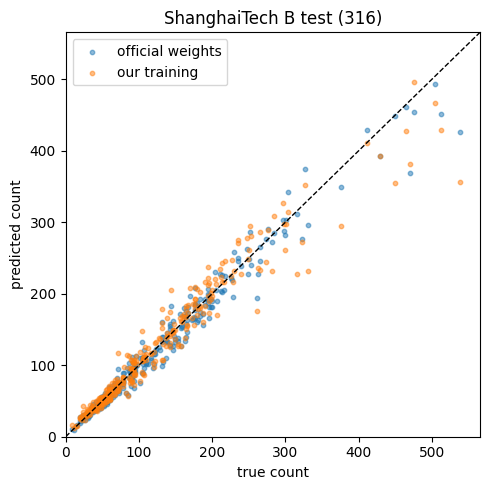

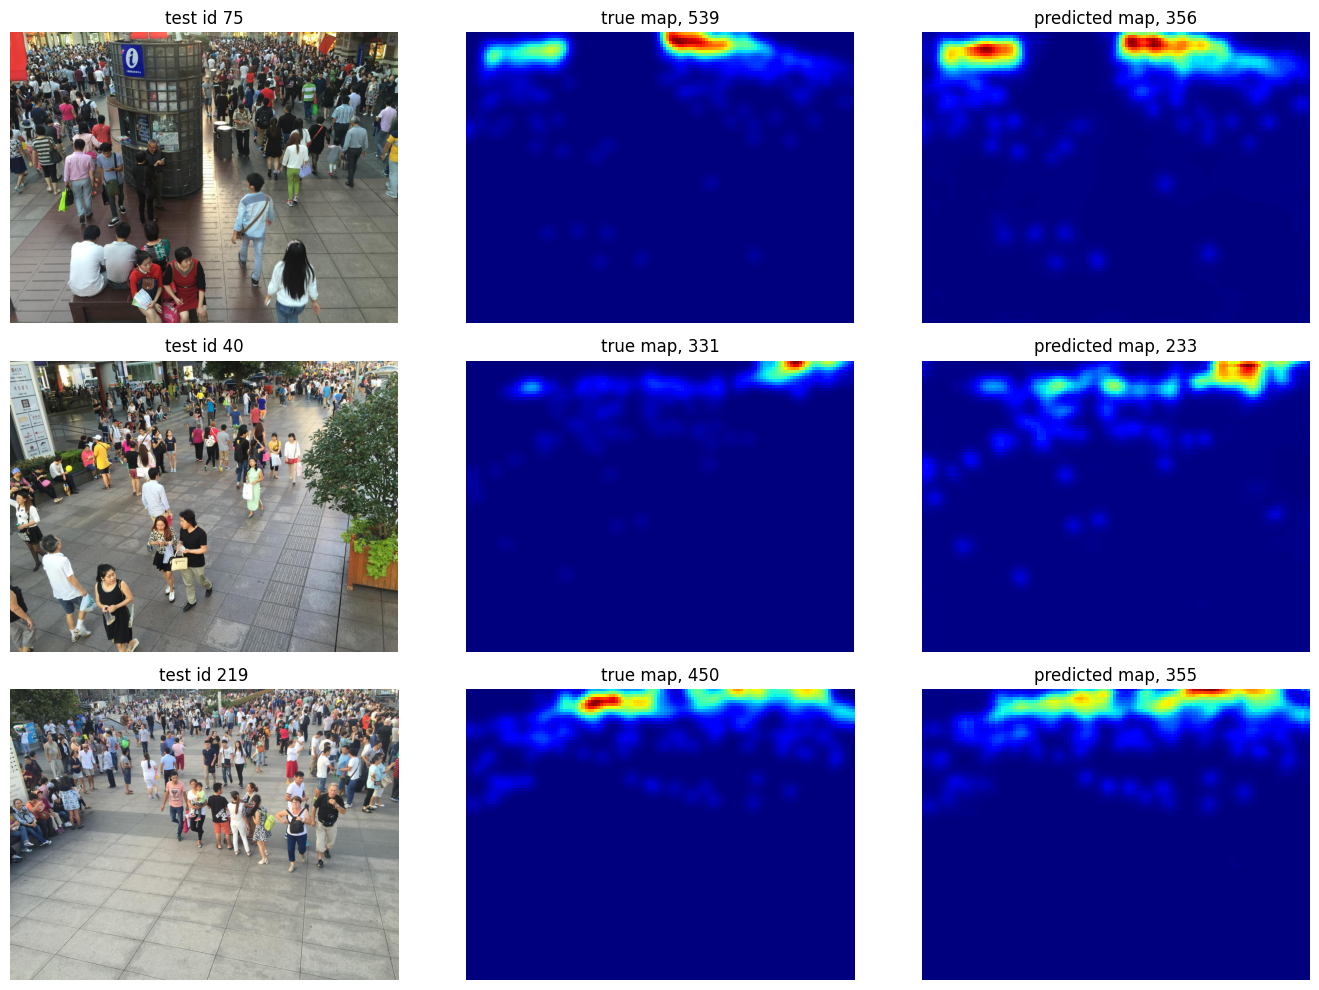

summary written: /kaggle/working/outputs/E004/summary.json


In [15]:
import json, shutil
import matplotlib.pyplot as plt

PAPER = dict(MAE=10.6, RMSE=16.0)

def find_best_weights():
    """Purpose: locate the weights of the committed training run. Only real FILES under
    /kaggle/input are accepted (Kaggle unzips uploaded .pth files into folders, which
    cannot be loaded); the notebook-output copy is preferred."""
    hits = [p for p in sorted(INPUT.rglob("best_adam.pth")) if p.is_file()]
    if not hits:
        raise FileNotFoundError("no loadable best_adam.pth file in /kaggle/input: attach the "
                                "06_csrnet_E004 notebook output")
    hits.sort(key=lambda p: "notebooks" not in str(p))   # notebook output first
    if len(hits) > 1:
        print("several copies found, using the first:", hits)
    return hits[0]

def load_trained(path):
    """Purpose: build a CSRNet and load our own best weights (a plain state_dict)."""
    net = CSRNet().to(DEVICE)
    net.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    return net.eval()

def by_density(df, edges=(0, 50, 100, 200, 10_000)):
    """Purpose: MAE and bias in bands of true head count, to show where errors come from."""
    band = pd.cut(df["gt"], edges, right=False)
    return (df.assign(band=band, abs_err=df["err"].abs())
              .groupby("band", observed=True)
              .agg(images=("id", "count"), MAE=("abs_err", "mean"), bias=("err", "mean"))
              .round(2))

def copy_from_input(name):
    """Purpose: copy a file saved by the training run (log, curve) from /kaggle/input
    into this session's results folder, so Cell 9 packs it."""
    hits = sorted(INPUT.rglob(name))
    if hits:
        shutil.copy(hits[0], OUT6 / name)
    return bool(hits)

# ---- clean up the leftover from the short interactive test ----
shutil.rmtree(OUT6 / "ckpt", ignore_errors=True)

# ---- test-set evaluation of the committed model (same weights -> same numbers) ----
test_df = shb[shb.role == "test"]
W = find_best_weights()
print("weights:", W)
assert str(W).startswith("/kaggle/input/"), "wrong weights file"
ours = load_trained(W)
res = evaluate(ours, test_df, desc="our model on test")
res.to_csv(OUT6 / "ours_adam_test.csv", index=False)
off = pd.read_csv(OUT6 / "official_partB_test.csv")          # from Cell 5

s_ours, s_off = summarize(res), summarize(off)
table = pd.DataFrame([dict(model="paper (reported)", **PAPER, bias=np.nan),
                      dict(model="official weights, our code", **s_off),
                      dict(model="our training (adam)", **s_ours)]).round(2)
print(table.to_string(index=False))
print("\nour model by crowd size:\n", by_density(res).to_string())
print("\nverdict:", "PASS (MAE <= 14)" if s_ours["MAE"] <= 14 else
      "ACCEPTABLE, note the gap (14-20)" if s_ours["MAE"] <= 20 else "FAIL (> 20): look for a bug")
print("expected from the committed run: MAE 12.74, RMSE 22.53, bias -0.28")

# ---- pictures: predicted vs true, and the 3 worst images ----
# note: use df["gt"], never df.gt (df.gt is pandas' "greater than" method)
fig, ax = plt.subplots(figsize=(5, 5))
m = max(res["gt"].max(), res["pred"].max(), off["pred"].max()) * 1.05
ax.scatter(off["gt"], off["pred"], s=10, alpha=.5, label="official weights")
ax.scatter(res["gt"], res["pred"], s=10, alpha=.5, label="our training")
ax.plot([0, m], [0, m], "k--", lw=1); ax.set_xlim(0, m); ax.set_ylim(0, m)
ax.set_xlabel("true count"); ax.set_ylabel("predicted count"); ax.legend(); ax.set_title("ShanghaiTech B test (316)")
plt.tight_layout(); plt.savefig(OUT6 / "test_scatter.png", dpi=100); plt.show()

worst = res.reindex(res["err"].abs().sort_values(ascending=False).index).head(3)
fig, axs = plt.subplots(3, 3, figsize=(14, 10))
for row, r in zip(axs, worst.itertuples()):
    t = test_df[test_df["id"] == r.id].iloc[0]
    img = cv2.cvtColor(cv2.imread(str(t.image)), cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        pm = ours(load_image_tensor(t.image).unsqueeze(0).to(DEVICE))[0, 0].cpu().numpy()
    gm = np.load(CACHE / f"test_{r.id}.npy")
    row[0].imshow(img); row[0].set_title(f"test id {r.id}")
    row[1].imshow(gm, cmap="jet"); row[1].set_title(f"true map, {r.gt}")
    row[2].imshow(pm, cmap="jet"); row[2].set_title(f"predicted map, {r.pred:.0f}")
    for a in row: a.axis("off")
plt.tight_layout(); plt.savefig(OUT6 / "worst3.png", dpi=90); plt.show()

# ---- training log and curve from the committed run, then the summary ----
has_log = copy_from_input("train_log_adam.csv")
copy_from_input("train_curve_adam.png")
lg = pd.read_csv(OUT6 / "train_log_adam.csv") if has_log else None
summary = dict(experiment="E004", dataset="ShanghaiTech Part B",
               recipe="Adam lr 1e-5, batch 1, random 384x512 crops + flips, early stop patience 30",
               weights=str(W),
               best_val_mae=float(lg.val_mae.min()) if lg is not None else 15.78,
               best_epoch=int(lg.loc[lg.val_mae.idxmin(), "epoch"]) if lg is not None else 51,
               epochs_run=int(len(lg)) if lg is not None else 81,
               ours=s_ours, official_weights=s_off, paper=PAPER)
(OUT6 / "summary.json").write_text(json.dumps(summary, indent=2))
print("summary written:", OUT6 / "summary.json")

## Cell 9: Collect the results

This cell copies the small result files (tables, logs, pictures, summary) into one folder, results_E004, which you download and put in the repo under results/E004/. The model weights (about 65 MB each) are left out, because they are too big for git. They stay in the Kaggle output, and E005 attaches them from there.

In [16]:
import shutil

def pack_results(src, dst, skip=(".pth", ".tmp")):
    """Purpose: copy the small result files (csv, json, png) into one folder for git;
    model weights are left out because they are too large for the repo."""
    dst.mkdir(parents=True, exist_ok=True)
    kept = []
    for p in sorted(src.glob("*")):
        if p.is_file() and p.suffix not in skip:
            shutil.copy(p, dst / p.name)
            kept.append((p.name, p.stat().st_size))
    return kept

PACK = Path("/kaggle/working/results_E004")
files = pack_results(OUT6, PACK)
for name, size in files:
    print(f"{size/1024:8.1f} KB  {name}")
print(f"\n{len(files)} files in {PACK}  (download this folder -> repo results/E004/)")
print("weights (not for git):", [f"{p.name} {p.stat().st_size/1e6:.0f} MB" for p in sorted((OUT6 / 'ckpt').glob('*.pth'))])

   517.4 KB  density_example.png
    13.6 KB  official_partB_test.csv
    13.6 KB  ours_adam_test.csv
   155.8 KB  shb_index.csv
     0.6 KB  summary.json
    43.2 KB  test_scatter.png
    67.1 KB  train_curve_adam.png
     2.2 KB  train_log.csv
     9.1 KB  train_log_adam.csv
   761.0 KB  worst3.png

10 files in /kaggle/working/results_E004  (download this folder -> repo results/E004/)
weights (not for git): []


In [17]:
import shutil
from IPython.display import FileLink, display

def zip_for_download(folder, name):
    """Purpose: zip a results folder into /kaggle/working and show a clickable
    download link (Kaggle downloads single files, not folders)."""
    archive = shutil.make_archive(f"/kaggle/working/{name}", "zip", root_dir=folder)
    print(f"{archive}  ({Path(archive).stat().st_size/1024:.0f} KB)")
    os.chdir("/kaggle/working")                 # FileLink needs a path relative to the working dir
    display(FileLink(Path(archive).name))

zip_for_download("/kaggle/working/results_E004", "results_E004")

/kaggle/working/results_E004.zip  (1404 KB)


/kaggle/working/results_E004.zip